In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

kirb21_df = pd.read_csv("https://raw.githubusercontent.com/smart-stats/ds4bio_book/main/book/assetts/kirby21AllLevels.csv")
print(kirb21_df)

       Unnamed: 0                 rawid              roi  volume   min    max  \
0               1  kirby127a_3_1_ax.img  Telencephalon_L  531111   0.0  374.0   
1               2  kirby127a_3_1_ax.img  Telencephalon_R  543404   0.0  300.0   
2               3  kirby127a_3_1_ax.img   Diencephalon_L    9683  15.0  295.0   
3               4  kirby127a_3_1_ax.img   Diencephalon_R    9678  10.0  335.0   
4               5  kirby127a_3_1_ax.img    Mesencephalon   10268  55.0  307.0   
...           ...                   ...              ...     ...   ...    ...   
16715       16716  kirby959a_3_1_ax.img   Caudate_tail_L     406  65.0  248.0   
16716       16717  kirby959a_3_1_ax.img   Caudate_tail_R     311  70.0  270.0   
16717       16718  kirby959a_3_1_ax.img   Chroid_LVetc_L     399  15.0  229.0   
16718       16719  kirby959a_3_1_ax.img   Chroid_LVetc_R     323  14.0  211.0   
16719       16720  kirby959a_3_1_ax.img     IV_ventricle    3107   1.0  249.0   

           mean      std  t

467063
470488
937551
0.7845516583473847
0.8348063710737297
   type  level  total_volume
0     1      1       1195015
1     1      2       1195021
2     1      3       1195034
3     1      4       1195065
4     1      5       1195124
5     2      1       1195015
6     2      2       1195022
7     2      3       1195032
8     2      4       1195041
9     2      5       1195092


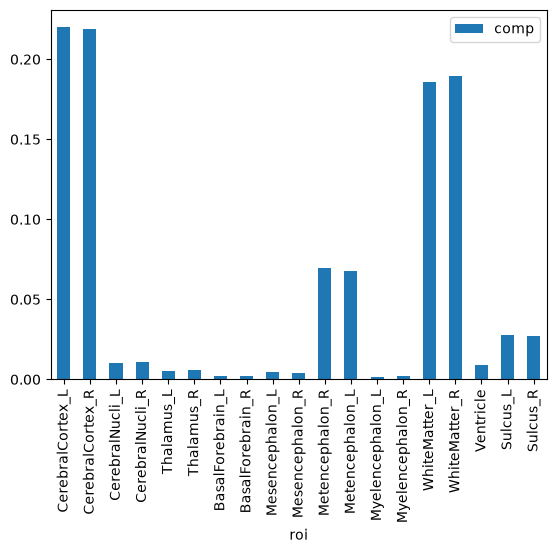

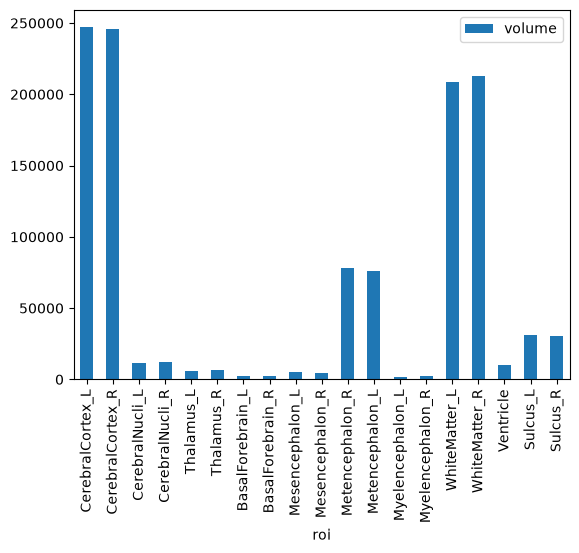

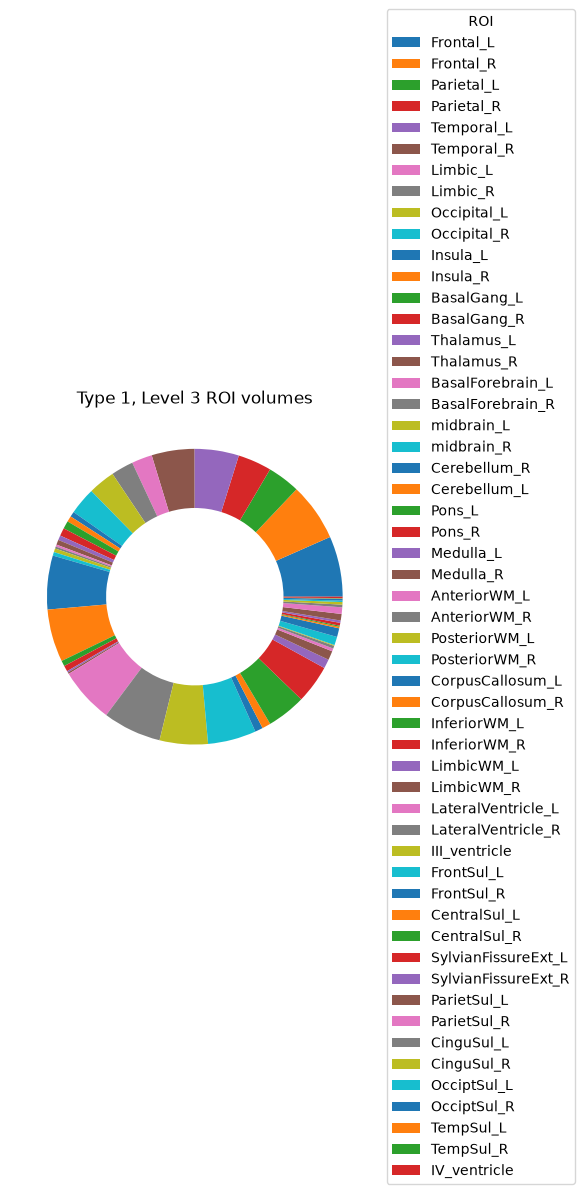

'\nuse of Claude Sonnet 5 to find code needed to make donut plot. \nprompts: asked for examples of code for matplot lib donut charts\nTested making plot with level 2 data to ensure it produced similar results to bar charts above.\n'

In [2]:
kirby906a_ax_df = kirb21_df.loc[(kirb21_df['rawid'] == "kirby906a_ax.img")]
telencephalon_L = kirby906a_ax_df.loc[(kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 1) & (kirby906a_ax_df['roi'] == "Telencephalon_L")] 
telencephalon_R = kirby906a_ax_df.loc[(kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 1) & (kirby906a_ax_df['roi'] == "Telencephalon_R")]
telencephalon_L_volume = telencephalon_L['volume'].values[0]
telencephalon_R_volume = telencephalon_R['volume'].values[0]
totalvolume = telencephalon_L_volume + telencephalon_R_volume
ICV = telencephalon_L['icv'].values[0]
TBV = telencephalon_L['tbv'].values[0]
ICV_fraction = totalvolume / ICV
TBV_fraction = totalvolume / TBV
print(telencephalon_L_volume)
print(telencephalon_R_volume)
print(totalvolume)
print(ICV_fraction)
print(TBV_fraction)

all_regions_df = (kirby906a_ax_df.groupby(['type', 'level'])['volume'].sum()).reset_index().rename(columns={'volume': 'total_volume'})
print(all_regions_df)


t1l2_df = kirby906a_ax_df.loc[(kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 2)]
t1l2_df = t1l2_df.assign(comp = lambda x: x.volume / x.tbv)
t1l2_df.plot.bar(x='roi',y='comp')
t1l2_df.plot.bar(x='roi',y='volume')

t1l3_df = kirby906a_ax_df.loc[(kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 3)]
fig, ax = plt.subplots()
wedges, _ = ax.pie(t1l3_df['volume'], wedgeprops={'width': 0.4})
ax.legend(wedges, t1l3_df['roi'], title="ROI", loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))
ax.set_title("Type 1, Level 3 ROI volumes")
plt.show()

'''
use of Claude Sonnet 5 to find code needed to make donut plot. 
prompts: asked for examples of code for matplot lib donut charts
Tested making plot with level 2 data to ensure it produced similar results to bar charts above.
'''



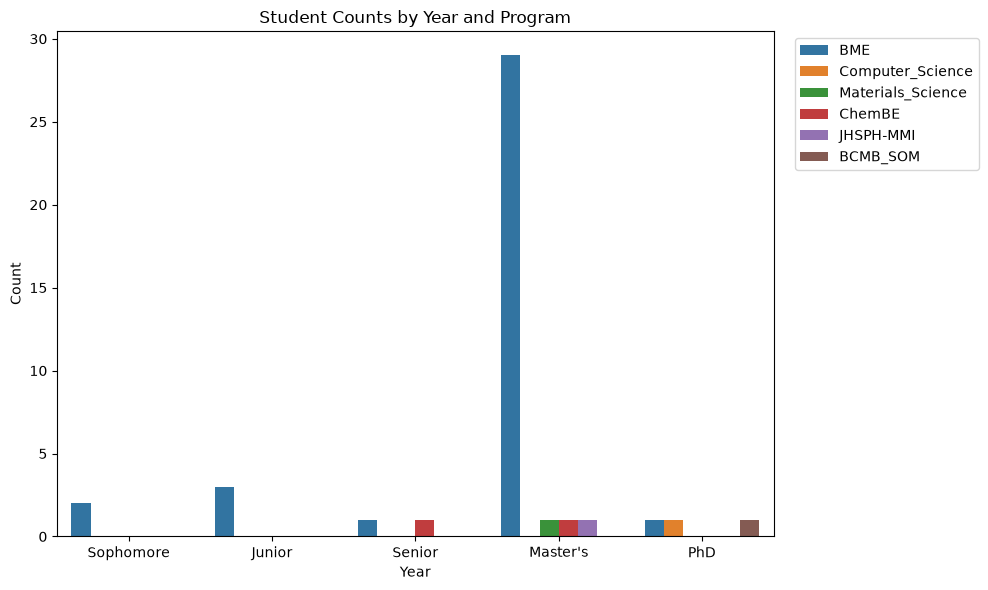

In [3]:
import seaborn as sns
class_interests_df = pd.read_csv("classInterests.txt", sep='\t')
plt.figure(figsize=(10, 6))
sns.countplot(data=class_interests_df, x='Year', hue='Program', order=['Sophomore', 'Junior', 'Senior', "Master's", 'PhD'])
plt.title("Student Counts by Year and Program")
plt.ylabel("Count")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [4]:
gene_expression_df = pd.read_csv("GSE5859_exprs.csv", index_col=0)
gene_expression_df_pt1 = gene_expression_df.sub(gene_expression_df.mean(axis=1), axis=0)
gene_expression_df_pt2 = gene_expression_df_pt1.sub(gene_expression_df_pt1.mean(axis=0), axis=1)
gene_expression_df_pt3 = gene_expression_df_pt2.div(gene_expression_df_pt2.std(axis=0), axis=1)
print(gene_expression_df_pt3)

                      GSM25581.CEL.gz  GSM25681.CEL.gz  GSM136524.CEL.gz  \
1007_s_at                   -0.062810        -1.694428         -0.797346   
1053_at                      0.484259         0.835005          1.434085   
117_at                       0.789673        -1.707110         -1.548943   
121_at                      -1.599798        -1.460817         -0.134750   
1255_g_at                    1.090032        -0.216675         -0.238137   
...                               ...              ...               ...   
AFFX-r2-Ec-bioC-5_at         0.763075         2.777651          3.006323   
AFFX-r2-Ec-bioD-3_at        -2.722110        -1.141065          3.360467   
AFFX-r2-Ec-bioD-5_at        -2.229208        -1.637114          4.049170   
AFFX-r2-P1-cre-3_at         12.457774        14.241719        -10.475605   
AFFX-r2-P1-cre-5_at         12.511658        14.456963        -11.579215   

                      GSM136707.CEL.gz  GSM25553.CEL.gz  GSM136676.CEL.gz  \
1007_s_at 

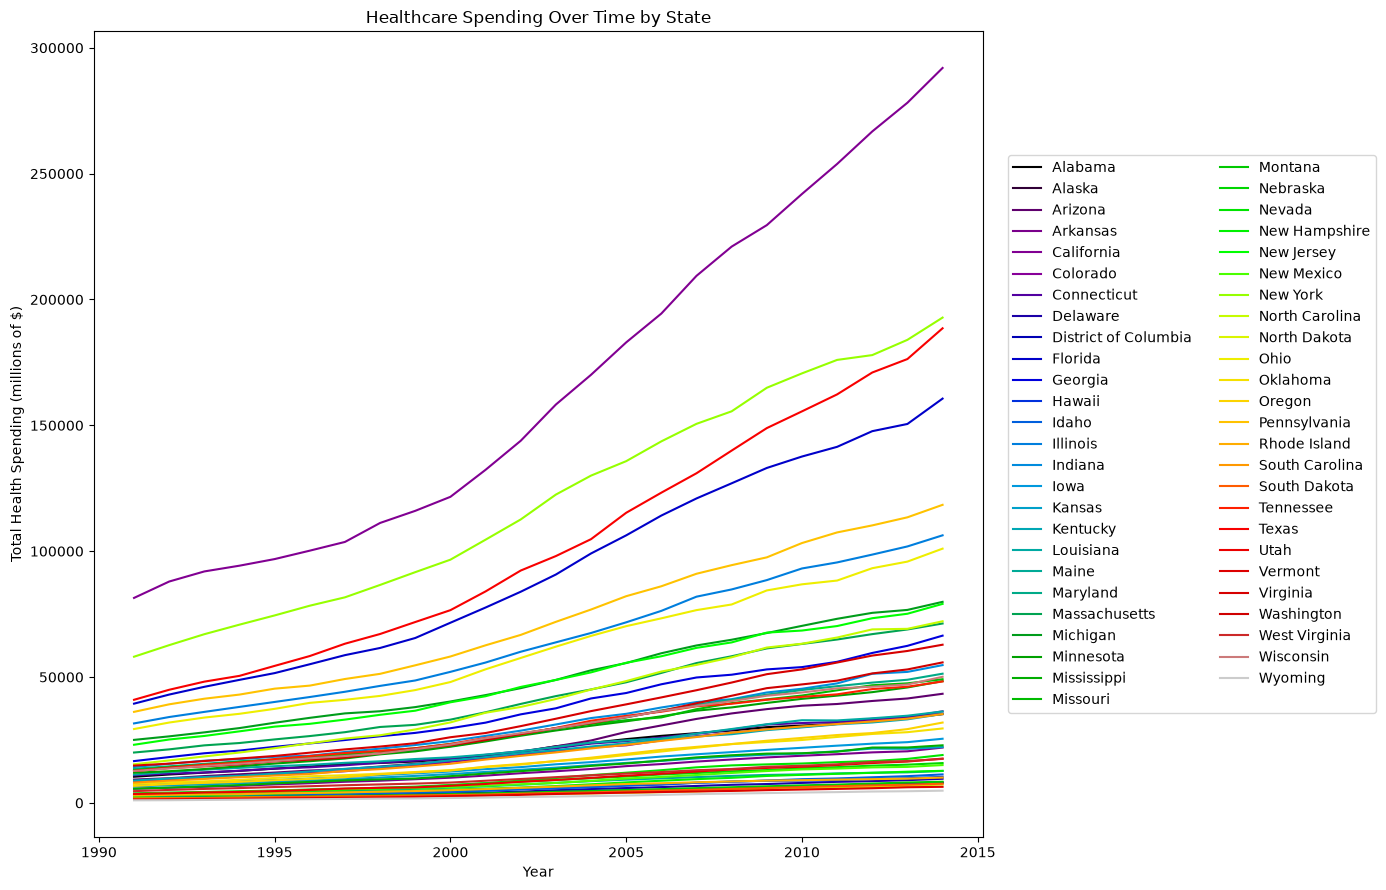

In [5]:
healthcare_df = pd.read_csv("https://raw.githubusercontent.com/jhu-advdatasci/2018/master/data/KFF/healthcare-spending.csv", skiprows=2)
year_cols = []
for c in healthcare_df.columns:
    if c != 'Location':
        year_cols.append(c)
healthcare_df = healthcare_df.dropna(subset=year_cols, how='all')
healthcare_df = healthcare_df.reset_index(drop=True)

healthcare_long_df = healthcare_df.melt(id_vars='Location', value_vars=year_cols, var_name='Year', value_name='Spending')
split_df = healthcare_long_df['Year'].str.split('__')
year = split_df.str[0]
healthcare_long_df['Year'] = year.astype(int)

states_long_df = healthcare_long_df[healthcare_long_df['Location'] != 'United States']
states = sorted(states_long_df['Location'].unique())
cmap = mpl.colormaps['nipy_spectral'].resampled(len(states)) 
fig, ax = plt.subplots(figsize=(14, 9))
for i, location in enumerate(states):
    group = states_long_df[states_long_df['Location'] == location]
    ax.plot(group['Year'], group['Spending'], label=location, color=cmap(i))
ax.set_xlabel('Year')
ax.set_ylabel('Total Health Spending (millions of $)')
ax.set_title('Healthcare Spending Over Time by State')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=2)
plt.tight_layout()
plt.show()

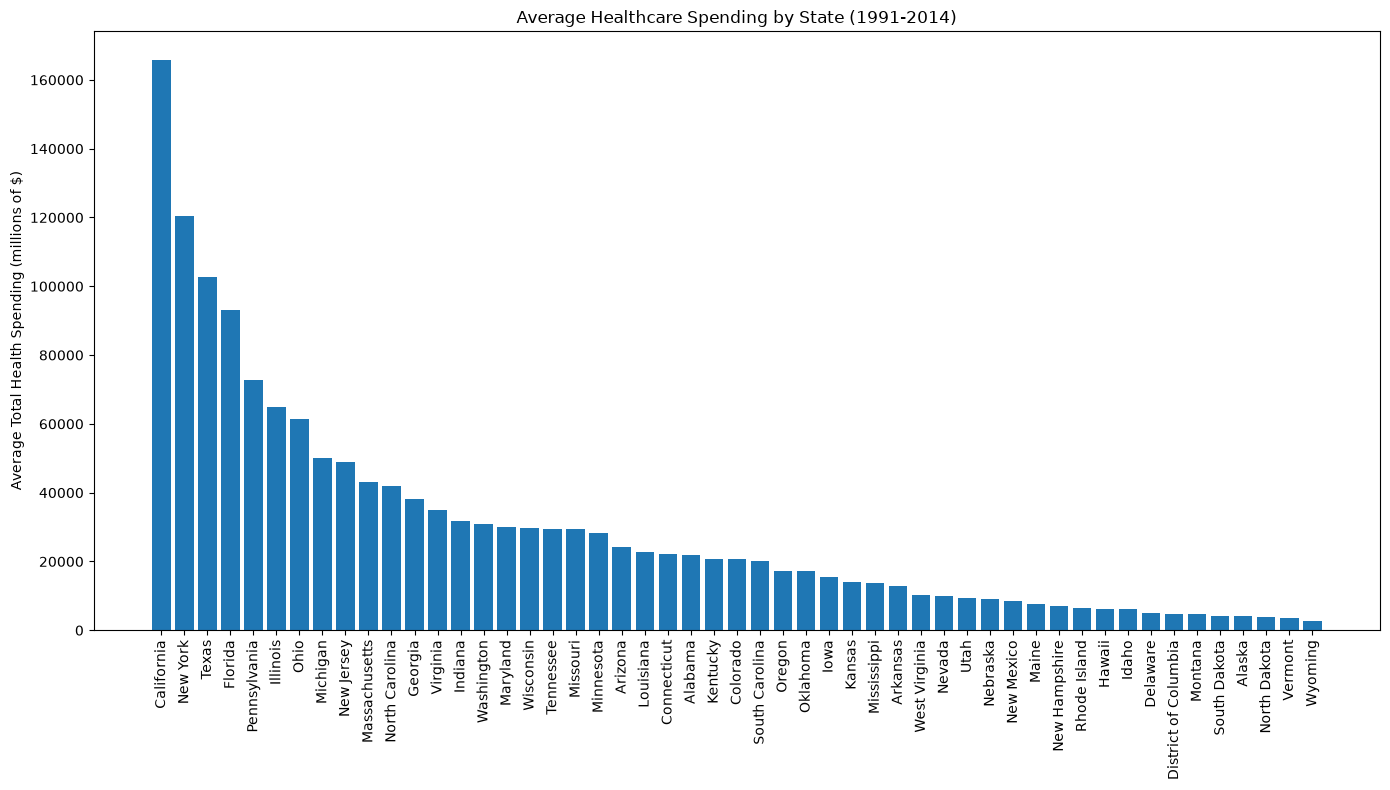

In [6]:
avg_spending = healthcare_df.set_index('Location')[year_cols].mean(axis=1)
avg_spending = avg_spending.drop('United States').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(avg_spending.index, avg_spending.values)
ax.set_xticks(range(len(avg_spending)))
ax.set_xticklabels(avg_spending.index, rotation=90)
ax.set_ylabel('Average Total Health Spending (millions of $)')
ax.set_title('Average Healthcare Spending by State (1991-2014)')
plt.tight_layout()
plt.show()